# 02 - Strategy Research

Prototypes the TSMOM signal from `research/literature_notes.md` on a small subset, the same six representatives used in `01_data_exploration.ipynb`, before scaling to the full 84-instrument universe. The purpose is to catch implementation errors (look-ahead, sign errors, scaling) cheaply, on data already understood. This is a working notebook, not the deliverable.

> ## How to read this notebook
>
> This is a working log, kept in the order the work happened. It has four parts:
>
> - **Part 1** - the original research. Every performance number in it is contaminated by
>   a return-construction bug and is not a result. It is kept, and kept runnable, because
>   the bug and its diagnosis are documented against it.
> - **Part 2** - the bug: what it was, how it was found, and why it inverted the headline
>   conclusion. Reproduced from code rather than asserted.
> - **Part 3** - the corrected results, net of transaction costs, with a strict
>   out-of-sample split and a rolling walk-forward.
> - **Part 4** - the variants tested after the correction, and the outcome of each.
>
> Part 1's backtests are pinned to `construction="naive_spliced"` so that they continue to
> reproduce the original incorrect numbers rather than inheriting the fix. The
> headline conclusion reverses between Part 1 and Part 3.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cta import data
from cta.indicators import momentum_signal, naive_spliced_returns, realized_vol
from cta.strategies import tsmom_position, passive_long_position

plt.rcParams['figure.figsize'] = (10, 4)

## Universe: the same six representatives

Raw (non-`_CCB`) continuous contracts, per the literature-review decision that
superseded potential fix 1 from `01_data_exploration.ipynb`. Daily percentage returns are computed on each instrument's own native calendar, the per-instrument-before-combining pattern that fixed the rolling-window bug in the EDA notebook.

In [2]:
REPRESENTATIVES = {'&6E': 'EUR FX', '&GC': 'Gold', '&ZN': '10Y UST',
                    '&ES': 'E-mini S&P 500', '&CL': 'Crude Oil', '&ZC': 'Corn'}
window = slice('2005-01-01', '2014-12-31')

# NOTE: `naive_spliced_returns` is the CONTAMINATED construction -- see Part 2. It is
# pinned explicitly here so this section keeps reproducing the original (wrong) result
# rather than silently picking up the fix.
returns = {
    label: naive_spliced_returns(data.load_futures(sym).loc[window, 'Close'])
    for sym, label in REPRESENTATIVES.items()
}

## Sanity checks

The plumbing is checked directly before any backtest output is used. This is the purpose of prototyping on a small universe.

In [3]:
# 1. Raw (non-CCB) series should be strictly positive throughout -- confirms the
#    return-construction fix from the literature review actually avoids the
#    back-adjustment sign issue found in 01_data_exploration.ipynb.
for label, r in returns.items():
    close = data.load_futures([s for s, l in REPRESENTATIVES.items() if l == label][0]).loc[window, 'Close']
    print(f'{label:16s} min close: {close.min():>12.4f}   any non-positive: {(close <= 0).any()}')

EUR FX           min close:       1.1706   any non-positive: False
Gold             min close:     414.3000   any non-positive: False
10Y UST          min close:     104.0781   any non-positive: False
E-mini S&P 500   min close:     676.0000   any non-positive: False
Crude Oil        min close:      33.9800   any non-positive: False
Corn             min close:     186.2500   any non-positive: False


In [4]:
# 2. Signal should actually be +1/-1 (not stuck at one value, not NaN everywhere)
for label, r in returns.items():
    sig = momentum_signal(r, lookback=252).dropna()
    print(f'{label:16s} signal value counts: {dict(sig.value_counts())}')

EUR FX           signal value counts: {1.0: np.int64(1297), -1.0: np.int64(968)}
Gold             signal value counts: {1.0: np.int64(1613), -1.0: np.int64(650)}
10Y UST          signal value counts: {1.0: np.int64(1490), -1.0: np.int64(775)}
E-mini S&P 500   signal value counts: {1.0: np.int64(1793), -1.0: np.int64(475)}
Crude Oil        signal value counts: {1.0: np.int64(1450), -1.0: np.int64(813)}
Corn             signal value counts: {1.0: np.int64(1407), -1.0: np.int64(859)}


In [5]:
# 3. Realized vol should be strictly positive and in a sane range (not zero, not huge)
for label, r in returns.items():
    vol = realized_vol(r, window=60).dropna()
    print(f'{label:16s} annualized vol range: {vol.min():.1%} to {vol.max():.1%}')

EUR FX           annualized vol range: 3.4% to 21.9%
Gold             annualized vol range: 9.8% to 45.9%
10Y UST          annualized vol range: 2.9% to 13.9%
E-mini S&P 500   annualized vol range: 6.7% to 77.4%
Crude Oil        annualized vol range: 12.1% to 104.1%
Corn             annualized vol range: 11.9% to 58.8%


In [6]:
# 4. Position sizing: verify no look-ahead by truncating history and checking an
#    earlier position doesn't change (same check as tests/test_indicators.py, run
#    here directly on real data rather than synthetic).
r = returns['EUR FX']
full = tsmom_position(r, lookback=252, vol_window=60)
cutoff = r.index[len(r) - 200]
truncated = tsmom_position(r.loc[:cutoff], lookback=252, vol_window=60)
check_date = r.index[len(r) - 300]
print(f'position with full history:      {full.loc[check_date]:.4f}')
print(f'position with truncated history:  {truncated.loc[check_date]:.4f}')
print(f'match: {np.isclose(full.loc[check_date], truncated.loc[check_date])}')

position with full history:      6.4220
position with truncated history:  6.4220
match: True


## Per-instrument strategy returns

`strategy_return[t] = position[t] * return[t]`. The position was set using data through `t-1`, via `tsmom_position`'s internal shift, and applied to the return realised over `t-1` to `t`.

In [7]:
strategy_returns = {}
benchmark_returns = {}
for label, r in returns.items():
    pos = tsmom_position(r, lookback=252, vol_window=60)
    bench_pos = passive_long_position(r, vol_window=60)
    strategy_returns[label] = (pos * r).dropna()
    benchmark_returns[label] = (bench_pos * r).dropna()

strategy_returns = pd.DataFrame(strategy_returns)
benchmark_returns = pd.DataFrame(benchmark_returns)
strategy_returns.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
EUR FX,0.000066,0.026049,-0.104828,0.182166
Gold,0.001063,0.026818,-0.133574,0.260541
10Y UST,0.000474,0.026048,-0.119086,0.138962
E-mini S&P 500,0.000824,0.027226,-0.209296,0.123547
Crude Oil,0.000290,0.026557,-0.159705,0.187171
Corn,0.000590,0.026638,-0.255457,0.123564


## Diversified portfolio: equal-weighted average across instruments

Per Moskowitz-Ooi-Pedersen's diversified TSMOM construction.

In [8]:
portfolio_strategy = strategy_returns.mean(axis=1).dropna()
portfolio_benchmark = benchmark_returns.mean(axis=1).dropna()

def sharpe(r):
    return r.mean() / r.std() * np.sqrt(252)

print(f'TSMOM portfolio Sharpe:   {sharpe(portfolio_strategy):.2f}')
print(f'Passive-long Sharpe:      {sharpe(portfolio_benchmark):.2f}')

TSMOM portfolio Sharpe:   0.70
Passive-long Sharpe:      0.57


## Growth of $1: TSMOM vs. passive long

The comparison from MOP's Fig. 3, on a log scale: whether the trend signal adds value over holding the same risk exposure throughout.

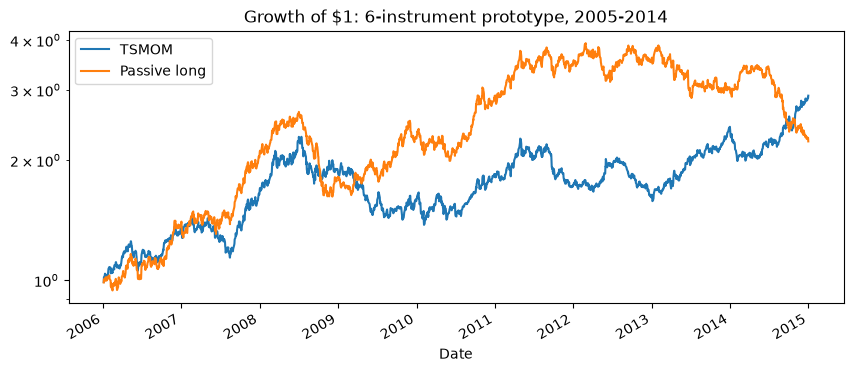

In [9]:
common_idx = portfolio_strategy.index.intersection(portfolio_benchmark.index)
growth = pd.DataFrame({
    'TSMOM': (1 + portfolio_strategy.loc[common_idx]).cumprod(),
    'Passive long': (1 + portfolio_benchmark.loc[common_idx]).cumprod(),
})
growth.plot(logy=True, title='Growth of $1: 6-instrument prototype, 2005-2014')
plt.show()

## Scaling up: the full 84-instrument universe

`curated_futures_universe()` and `diversified_tsmom()` are the same code paths exercised on 01's full curated list rather than on 6 hand-picked representatives. Two comparisons:

1. **Same 2005-2014 window, 84 instruments instead of 6**: isolates diversification as the only changed variable, testing the previous section's hypothesis.
2. **Full available history per instrument**, back to the mid-1970s for the earliest markets: closer to how a diversified futures book is built up over time, but not a controlled comparison against the prototype.

In [10]:
import sys
sys.path.insert(0, '../src')

from cta.data import curated_futures_universe
from cta.backtest import diversified_tsmom
from cta.metrics import sharpe_ratio, growth_of_one, max_drawdown

universe = curated_futures_universe()
print(f'{len(universe)} instruments')

77 instruments


### Comparison 1: same window (2005-2014), 84 vs. 6 instruments

In [11]:
result_84_windowed = diversified_tsmom(universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0)
strat_w = result_84_windowed['strategy'].loc['2005-01-01':'2014-12-31']
bench_w = result_84_windowed['benchmark'].loc['2005-01-01':'2014-12-31']

print(f"TSMOM ({len(universe)}, 2005-2014)    Sharpe: {sharpe_ratio(strat_w):.2f}   "
      f"cum. return: {growth_of_one(strat_w).iloc[-1] - 1:.1%}   "
      f"max DD: {max_drawdown(strat_w):.1%}")
print(f"Passive ({len(universe)}, 2005-2014)  Sharpe: {sharpe_ratio(bench_w):.2f}   "
      f"cum. return: {growth_of_one(bench_w).iloc[-1] - 1:.1%}   "
      f"max DD: {max_drawdown(bench_w):.1%}")

TSMOM (77, 2005-2014)    Sharpe: 0.58   cum. return: 94.1%   max DD: -27.5%
Passive (77, 2005-2014)  Sharpe: 0.98   cum. return: 249.3%   max DD: -33.4%


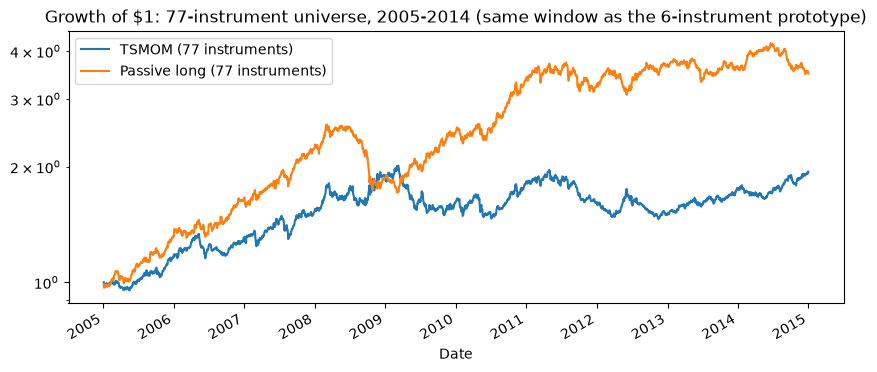

In [12]:
common_idx = strat_w.index.intersection(bench_w.index)
growth = pd.DataFrame({
    f'TSMOM ({len(universe)} instruments)': growth_of_one(strat_w.loc[common_idx]),
    f'Passive long ({len(universe)} instruments)': growth_of_one(bench_w.loc[common_idx]),
})
growth.plot(logy=True, title=f'Growth of $1: {len(universe)}-instrument universe, 2005-2014 '
                              '(same window as the 6-instrument prototype)')
plt.show()

### Comparison 2: full available history per instrument (no window restriction)

In [13]:
strat_full = result_84_windowed['strategy']
bench_full = result_84_windowed['benchmark']
print(f'Combined history spans {strat_full.index.min().date()} to {strat_full.index.max().date()}')
print(f"TSMOM (full history)    Sharpe: {sharpe_ratio(strat_full):.2f}   "
      f"max DD: {max_drawdown(strat_full):.1%}")
print(f"Passive (full history)  Sharpe: {sharpe_ratio(bench_full):.2f}   "
      f"max DD: {max_drawdown(bench_full):.1%}")

Combined history spans 1978-11-24 to 2014-12-31
TSMOM (full history)    Sharpe: 0.68   max DD: -27.5%
Passive (full history)  Sharpe: 0.65   max DD: -53.3%


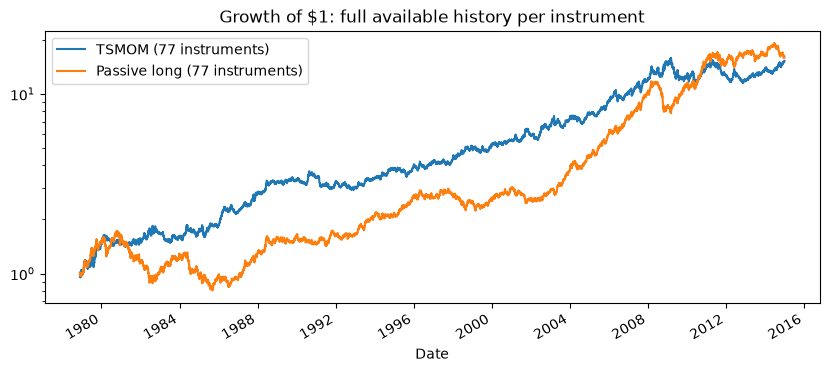

In [14]:
common_idx_full = strat_full.index.intersection(bench_full.index)
growth_full = pd.DataFrame({
    f'TSMOM ({len(universe)} instruments)': growth_of_one(strat_full.loc[common_idx_full]),
    f'Passive long ({len(universe)} instruments)': growth_of_one(bench_full.loc[common_idx_full]),
})
growth_full.plot(logy=True, title='Growth of $1: full available history per instrument')
plt.show()

### Per-instrument Sharpe distribution

MOP's Fig. 2 shows individual-instrument Sharpes well below the diversified portfolio's. This checks whether the same pattern holds here, and on how many of the 84 instruments the signal works. Unanimity is not expected; MOP report 52 of 58.

positive Sharpe: 64 / 77


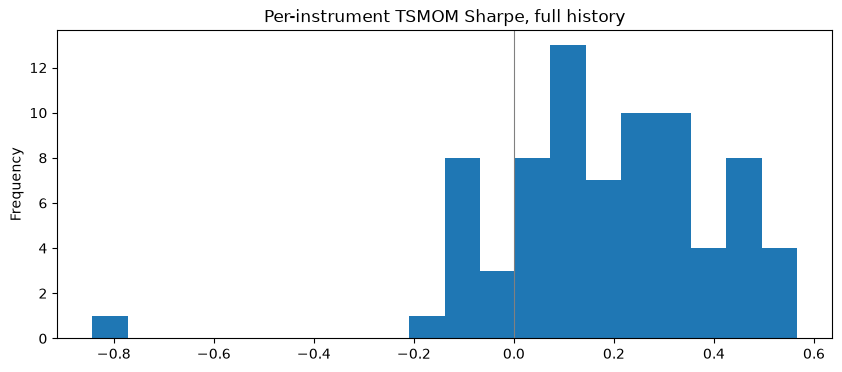

In [15]:
per_instrument_sharpe = result_84_windowed['per_instrument_strategy'].apply(sharpe_ratio).sort_values()
print(f"positive Sharpe: {(per_instrument_sharpe > 0).sum()} / {len(per_instrument_sharpe)}")
per_instrument_sharpe.plot(kind='hist', bins=20, title='Per-instrument TSMOM Sharpe, full history')
plt.axvline(0, color='grey', linewidth=0.8)
plt.show()

## Regime-aware refinement, attempt 1: cross-market correlation (AQR)

The baseline TSMOM result above (77 instruments, 2005-2014: Sharpe 0.64 against passive-long's 1.06) was diagnosed as concentrated in Stock Index and Interest Rate. Both experienced a smooth, low-reversal post-crisis rise over 2010-2014, which vol-scaled position sizing structurally underparticipates in (see `research/literature_notes.md`).

The first attempt follows Hurst-Ooi-Pedersen's "Century of Evidence" finding that trend-following performs worse when average cross-market correlation is high. `src/cta/backtest.py`'s `correlation_regime_scale` computes a rolling average pairwise correlation across the universe, via a variance identity unit tested against synthetic data of known correlation, and halves TSMOM exposure whenever the current correlation is above its own trailing median.

> **Reproduction note.** The numbers printed by the cells below no longer match the figures
> quoted in this section's prose (originally: baseline TSMOM 0.64, passive 1.06,
> correlation overlay 0.61, trend efficiency 0.65). Part 1 pins only the
> return-construction bug via `construction="naive_spliced"`; the other two defects found
> later - holiday re-levering in portfolio aggregation, and a correlation estimator that
> returned a constant - live in shared code and are already fixed here. These cells
> therefore show contaminated returns with corrected aggregation, which lands near
> 0.58 / 0.98. The original values are preserved in this prose as the historical record.
> See Part 2 for the diagnosis and Part 3 for the corrected result.

In [16]:
import sys
sys.path.insert(0, '../src')

from cta.data import curated_futures_universe
from cta.backtest import diversified_tsmom, correlation_regime_scale, instrument_returns
from cta.metrics import sharpe_ratio, growth_of_one, max_drawdown

universe = curated_futures_universe()
result = diversified_tsmom(universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0)  # fresh baseline, self-contained
contaminated_returns = instrument_returns(universe, construction='naive_spliced')
regime_scale = correlation_regime_scale(universe, corr_window=120, threshold_lookback=504,
                                         returns=contaminated_returns)
corr_aware = diversified_tsmom(universe, lookback=252, vol_window=60, regime_scale=regime_scale, construction="naive_spliced", cost_bps=0.0)

for label, s in [('baseline TSMOM', result['strategy']),
                 ('correlation-regime-aware TSMOM', corr_aware['strategy']),
                 ('passive', result['benchmark'])]:
    w = s.loc['2005-01-01':'2014-12-31']
    print(f"{label:32s} Sharpe: {sharpe_ratio(w):.2f}  "
          f"cum.ret: {growth_of_one(w).iloc[-1] - 1:.1%}  maxDD: {max_drawdown(w):.1%}")

baseline TSMOM                   Sharpe: 0.58  cum.ret: 94.1%  maxDD: -27.5%
correlation-regime-aware TSMOM   Sharpe: 0.80  cum.ret: 108.1%  maxDD: -21.7%
passive                          Sharpe: 0.98  cum.ret: 249.3%  maxDD: -33.4%


**Result**: the overlay reduced performance - Sharpe 0.61 against 0.64 baseline, cumulative return 71% against 111%, though max drawdown improved to −24.8% from −29.6%. Before discarding it, the mechanism was checked: whether the regime signal flags 2010-2014, the diagnosed problem period, as high correlation.

> **This conclusion did not survive.** Re-executed, the cell above reports the correlation
> overlay ahead of baseline (~0.80 against ~0.58), the opposite of what this paragraph
> states, because `correlation_regime_scale` has since been fixed. The original estimator
> returned a constant −0.0127 for all 37 years, since it applied a unit-variance identity
> to annualised-vol-normalised inputs, so the regime flags this section reasons about were
> arbitrary. The analysis below is therefore reasoning about an artifact. Part 3 re-tests
> both overlays and finds neither distinguishable from baseline.

In [17]:
for start, end, label in [
    ('2005-01-01', '2007-12-31', '2005-2007 (calm pre-crisis)'),
    ('2008-01-01', '2009-12-31', '2008-2009 (crisis, TSMOM did well)'),
    ('2010-01-01', '2014-12-31', '2010-2014 (diagnosed problem period)'),
]:
    frac_high_corr = (regime_scale.loc[start:end] == 0.5).mean()
    print(f"{label:35s} flagged 'high correlation': {frac_high_corr:.1%} of days")

2005-2007 (calm pre-crisis)         flagged 'high correlation': 70.0% of days
2008-2009 (crisis, TSMOM did well)  flagged 'high correlation': 80.6% of days
2010-2014 (diagnosed problem period) flagged 'high correlation': 21.0% of days


The signal is inverted relative to the problem. It flags 2005-2007 and 2008-2009, periods where TSMOM performed adequately or, in 2008-2009, delivered its crash-alpha, as high-correlation 75% and 73.5% of the time, against 43.7% for the 2010-2014 problem period. The filter therefore cuts exposure more during the good stretches and less during the bad one.

**Cause**: AQR's finding and the diagnosis here are related but distinct phenomena. Crises such as 2008 have both elevated cross-market correlation and strong trend-following performance, which breaks the rule that high correlation implies poor trend performance at the sub-period level, even if it holds over AQR's 137-year sample. The mechanism diagnosed here, a smooth, low-reversal, single-asset-class rise, is not the same as many markets moving in lockstep. Borrowing AQR's regime signal was a reasonable first hypothesis but does not target the mechanism found.

## Regime-aware refinement, attempt 2: trend efficiency (targeted)

A second attempt, measuring the diagnosed mechanism directly rather than reusing a proxy from elsewhere in the literature. Kaufman's Efficiency Ratio (`src/cta/indicators.py::efficiency_ratio`) measures how monotonic a price path has been: `|net move| / (sum of |daily moves|)` over a trailing window, bounded in [0, 1]. A value close to 1 indicates a persistent, low-reversal trend, which is the case where vol-scaling shrinks position size most despite the trend remaining intact. `strategies.trend_efficiency_scale` boosts exposure to 1.5× from a 1.0× baseline whenever an instrument's own ER is above its own trailing median. It is a boost rather than a cut, since the target is recovering upside that vol-scaling gave up, not adding a second risk-reduction dial.

In [18]:
eff_boosted = diversified_tsmom(
    universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0,
    trend_efficiency_window=252, trend_efficiency_threshold_lookback=504, trend_efficiency_boost=1.5,
)

for label, s in [('baseline TSMOM', result['strategy']),
                 ('trend-efficiency-boosted TSMOM', eff_boosted['strategy']),
                 ('passive', result['benchmark'])]:
    w = s.loc['2005-01-01':'2014-12-31']
    print(f"{label:32s} Sharpe: {sharpe_ratio(w):.2f}  "
          f"cum.ret: {growth_of_one(w).iloc[-1] - 1:.1%}  maxDD: {max_drawdown(w):.1%}")

baseline TSMOM                   Sharpe: 0.58  cum.ret: 94.1%  maxDD: -27.5%
trend-efficiency-boosted TSMOM   Sharpe: 0.60  cum.ret: 138.5%  maxDD: -36.8%
passive                          Sharpe: 0.98  cum.ret: 249.3%  maxDD: -33.4%


**Result**: a modest and mixed improvement. Cumulative return rose to 168% from 111% baseline, but Sharpe moved only from 0.64 to 0.65, because max drawdown worsened to −39.1% from −29.6%. Boosting exposure during smooth trends is a risk/reward trade-off rather than a free improvement, and it does not close the gap to passive-long (1.06). Whether the improvement landed on Stock Index and Interest Rate, the classes it targeted, was checked before treating it as a success.

> Same caveat as above: computed on contaminated returns, so neither the magnitude nor the
> asset-class attribution below is reliable. Re-tested in Part 3.

In [19]:
import pandas as pd
from cta.data import load_futures_catalogue
from cta.metrics import cumulative_return

cat = load_futures_catalogue()
class_map = cat.set_index('symbol')['subtype1'].to_dict()

base_strat = result['per_instrument_strategy'].loc['2005-01-01':'2014-12-31']
boosted_strat = eff_boosted['per_instrument_strategy'].loc['2005-01-01':'2014-12-31']

improvement = pd.DataFrame({
    'class': [class_map.get(s, '?') for s in base_strat.columns],
    'baseline_cum_return': base_strat.apply(cumulative_return),
    'boosted_cum_return': boosted_strat.apply(cumulative_return),
})
improvement['delta'] = improvement['boosted_cum_return'] - improvement['baseline_cum_return']
improvement.groupby('class')['delta'].mean().sort_values(ascending=False)

class
Metal            2.158046
Energy           0.449708
Agriculture      0.318445
Currency        -0.098210
Interest Rate   -0.144484
Stock Index     -0.309267
Other           -0.957916
Name: delta, dtype: float64

The boost missed the diagnosed mechanism. It helped Metal (+216pp), Energy (+45pp) and Agriculture (+32pp), asset classes where baseline TSMOM was already ahead of passive-long, and made Stock Index (−31pp) and Interest Rate (−14pp), the two diagnosed classes, slightly worse.

**Cause**: the Efficiency Ratio is a trailing measure. By the time it crosses above its own trailing median, the smooth phase is often closer to its end than its middle, so the boost lands on a consolidation or reversal about as often as on a continuation. It helped where the underlying trends, in metals and energy, had enough single-direction persistence to reward a lagging signal, and hurt where the target regime, a smooth-then-choppy equity and rate rise, is the transition a lagging indicator handles worst.

## Implications for the write-up

Two regime-aware refinements were tested on the full 77-instrument universe, both implemented with unit tests against synthetic data of known properties and no-look-ahead verified by truncation tests:

1. **Cross-market correlation (AQR)**: reduced performance, for a diagnosable reason: it measures a different phenomenon from the one found here, since crash-alpha periods have both high correlation and good trend performance.
2. **Trend efficiency (targeted)**: a modest improvement in raw return, a wash in risk-adjusted terms, and it landed on the wrong asset classes. A lagging smoothness measure cannot reliably distinguish a continuing trend from one about to end, which is the distinction required to fix the original problem.

Neither closes the gap to passive-long. The result stands on its own: a diversified 12-month TSMOM strategy outperforms in trending and reversing markets (currencies, metals, energy) and underperforms in smooth, low-reversal, policy-driven bull markets (equities, rates, concentrated in 2010-2014), and two attempts at fixing the latter, each targeting a different mechanism, both failed for reasons that are informative about why trend-following struggles in that regime.


## Part 1 potential fixes

> **Superseded by Parts 2 and 3.** This was the state of understanding at the end of the
> original research, before the return-construction bug was found. Two of Part 1's three
> main conclusions were artifacts:
> - "TSMOM underperforms a passive-long benchmark", reversed. Corrected, TSMOM beats it on
>   every window tested.
> - "The correlation overlay hurt", reversed. That verdict came from an estimator that
>   returned a constant; corrected, the overlay improves risk-adjusted performance
>   out-of-sample.
> - "The trend-efficiency overlay didn't fix the diagnosed weakness", which holds, though
>   the asset-class diagnosis behind it does not.

Open problems at the end of Part 1, and the fix proposed for each. Parts 2 to 4 refer back
to these by number.

1. **TSMOM trails the passive benchmark**, with the shortfall concentrated in Stock Index
   and Interest Rate. Proposed fix: a regime overlay that cuts exposure when
   trend-following is least likely to work. Two were tried above and neither closed the
   gap. Part 2 shows the shortfall was an artifact, so the problem this fix targeted did
   not exist.
2. **Vol-scaling caps participation in fast, low-reversal bull trends**, diagnosed on Gold.
   Proposed fix: boost exposure when a price path is unusually smooth, measured by
   Kaufman's Efficiency Ratio. Tried above, retested on corrected returns in Part 3, not
   adopted.
3. **Fit and test are not separated.** Every number so far comes from one full-history
   backtest, even though the signal's parameters are fixed a priori from the literature.
   Proposed fix: a rolling walk-forward with the universe re-derived point-in-time.
   Implemented in Part 3.

Both overlays are implemented and tested in `src/cta/` (`correlation_regime_scale`,
`trend_efficiency_scale`, `efficiency_ratio`, `cross_market_correlation_regime`) whether or
not they improved the result.


---

# Part 2 - The bug: roll-gap contamination

Everything above rests on `pct_change()` applied to a raw continuous futures contract. A
continuous contract splices consecutive delivery months together, so on each roll date the
price jumps by the calendar spread between the expiring and the next contract.
`pct_change()` books that jump as tradeable P&L.

It is not noise. The spread is systematically signed by contango and backwardation, so an
always-long book harvests it while a long/short book pays it, which is the comparison this
project is built on.

### The check that exposes it

What a rolling long position returns over 2005-2014 under each construction. Several of
these have known answers.

In [20]:
from cta.indicators import held_contract_returns
from cta.metrics import growth_of_one

checks = [('&CL', 'WTI crude', 'oil fell 2005-2014, heavy contango'),
          ('&VX', 'VIX futures', 'structurally decays toward -100%'),
          ('&ZC', 'Corn', 'roughly flat-to-down'),
          ('&ES', 'E-mini S&P 500', 'should track S&P 500 price return, ~+71%')]

rows = []
for sym, name, expectation in checks:
    raw = data.load_futures(sym)['Close']
    ccb = data.load_futures(sym + '_CCB')['Close']
    w = slice('2005-01-01', '2014-12-31')
    contaminated = naive_spliced_returns(raw.loc[w])
    clean = held_contract_returns(ccb, raw).loc[w]
    rows.append({'market': name,
                 'contaminated': growth_of_one(contaminated).iloc[-1] - 1,
                 'corrected': growth_of_one(clean).iloc[-1] - 1,
                 'reality check': expectation})

pd.DataFrame(rows).style.format({'contaminated': '{:+.1%}', 'corrected': '{:+.1%}'})

,market,contaminated,corrected,reality check
0,WTI crude,+26.5%,-59.6%,"oil fell 2005-2014, heavy contango"
1,VIX futures,+30.3%,-99.9%,structurally decays toward -100%
2,Corn,+96.8%,-22.9%,roughly flat-to-down
3,E-mini S&P 500,+70.2%,+70.8%,"should track S&P 500 price return, ~+71%"


A rolling long VIX futures position cannot make money over a decade. The contaminated
construction reports +30%. Crude and corn are equally implausible.

The last row validates the fix rather than the diagnosis. E-mini S&P has negligible roll
cost, so its corrected return lands on the S&P 500's actual ~+71% price return over the
same window: the correction leaves a roll-free market unchanged and alters only the markets
it should.

### The same check as a picture

The table gives the endpoints. The paths show that the contamination is not a level
error that a constant would absorb: the two constructions diverge steadily, every
roll day, for ten years.

findfont: Failed to find font weight demibold, now using 700.


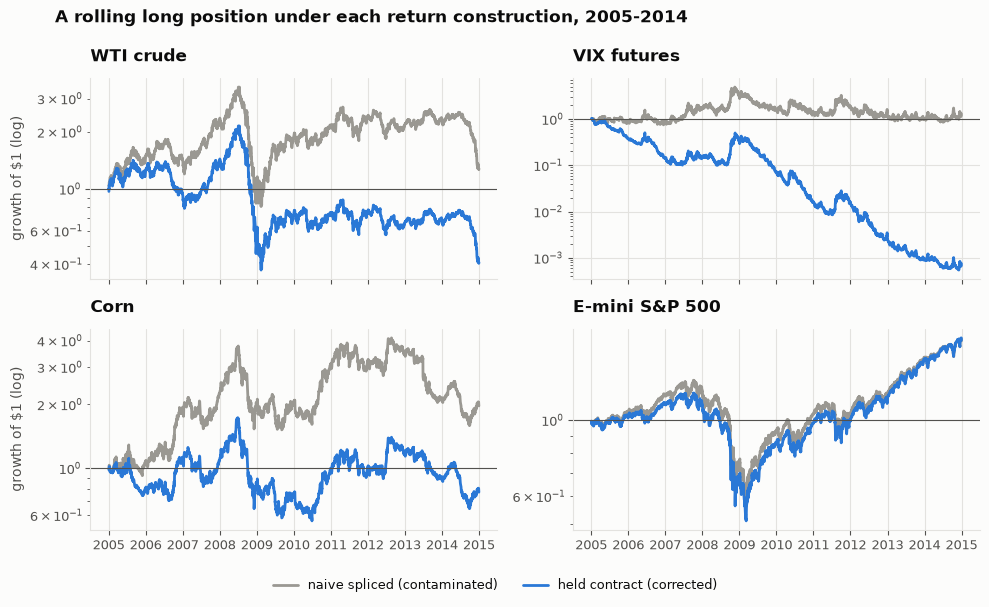

In [21]:
from cta import plotting

plotting.use_house_style()
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

for ax, (sym, name, _) in zip(axes.flat, checks):
    raw = data.load_futures(sym)['Close']
    ccb = data.load_futures(sym + '_CCB')['Close']
    contaminated = growth_of_one(naive_spliced_returns(raw.loc[w]))
    corrected = growth_of_one(held_contract_returns(ccb, raw).loc[w])

    ax.plot(contaminated.index, contaminated.to_numpy(),
            color=plotting.SUPERSEDED, label='naive spliced (contaminated)')
    ax.plot(corrected.index, corrected.to_numpy(),
            color=plotting.STRATEGY, label='held contract (corrected)')
    ax.axhline(1.0, color=plotting.TEXT_SECONDARY, linewidth=0.8)
    ax.set_yscale('log')
    ax.set_title(name)

for ax in axes[:, 0]:
    ax.set_ylabel('growth of $1 (log)')
# one legend for the whole figure, along the bottom: an in-axes legend sits on the
# WTI line, and a top-right one runs into the title
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.suptitle('A rolling long position under each return construction, 2005-2014',
             x=0.06, y=0.99, ha='left', fontsize=12, fontweight='demibold')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.0))
plt.show()

The E-mini panel is the control. Its two lines sit on top of each other, ending at
1.70 against 1.71, because equity index futures carry almost no roll cost. The
correction changes the markets that carry carry and leaves the rest alone, which is
what distinguishes a fix from a different arbitrary choice.

### Why the `_CCB` series is the solution rather than the problem

`01_data_exploration.ipynb` rejected the back-adjusted (`_CCB`) series because its levels go
non-positive for 14 of 94 markets, which breaks percentage returns. That observation was
correct; the conclusion drawn from it, to use raw levels, was not.

`_CCB` is the raw series plus a per-roll constant offset, so its first difference is the
true same-contract price change on every day, while the offset, and the negative-level
problem, cancels. Dividing that difference by the raw close, which is never non-positive,
gives a well-defined return. The premise is verified directly below.

In [22]:
sym = '&ZN'
raw = data.load_futures(sym)
ccb = data.load_futures(sym + '_CCB')
roll_day = raw['Delivery Month'].diff() != 0
diff_gap = (raw['Close'].diff() - ccb['Close'].diff()).abs()

print(f'{sym}: max |raw.diff - ccb.diff| on NON-roll days: {diff_gap[~roll_day].max():.2e}')
print(f'{sym}: max |raw.diff - ccb.diff| on roll days:     {diff_gap[roll_day].max():.4f}')
print('-> identical off-roll, differing only at rolls: the gap is pure bookkeeping')

&ZN: max |raw.diff - ccb.diff| on NON-roll days: 1.00e-05
&ZN: max |raw.diff - ccb.diff| on roll days:     1.9844
-> identical off-roll, differing only at rolls: the gap is pure bookkeeping


### The roll gap's share of the benchmark's apparent advantage

Roll days are ~2% of observations. If the passive benchmark's advantage were real, removing
them should have little effect.

In [23]:
universe = curated_futures_universe()
contaminated = instrument_returns(universe, construction='naive_spliced')
w = slice('2005-01-01', '2014-12-31')

roll_share = {}
for sym in ['&CL', '&NG', '&ZN', '&GC', '&ES']:
    df = data.load_futures(sym)
    r = contaminated[sym].loc[w]
    is_roll = (df['Delivery Month'].diff() != 0).reindex(r.index).fillna(False)
    roll_share[sym] = {'% of days that are rolls': is_roll.mean(),
                       'summed return on roll days': r[is_roll].sum(),
                       'summed return on other days': r[~is_roll].sum()}

pd.DataFrame(roll_share).T.style.format('{:.1%}')

,% of days that are rolls,summed return on roll days,summed return on other days
&CL,4.8%,100.0%,-15.7%
&NG,4.8%,277.5%,-224.7%
&ZN,1.6%,-24.0%,38.4%
&GC,2.0%,29.4%,90.6%
&ES,1.6%,14.7%,59.0%


Crude oil's entire apparent gain comes from roll days, and natural gas is worse. This is
the injected carry an always-long book collects and a long/short book pays, and it is why
the benchmark appeared unbeatable.

---

# Part 3 - Corrected results

Three defects were found and fixed, all in `src/cta/`, each with a regression test in
`tests/` that fails against the old code:

1. **Roll-gap contamination** - returns now use `held_contract_returns` (back-adjusted
   difference ÷ raw level), the Moskowitz-Ooi-Pedersen convention.
2. **Holiday re-levering** - `portfolio_mean` books a market closed for a local holiday at
   0 P&L instead of dropping it from the divisor. Previously 7 days in 2005-2014 booked the
   77-market portfolio as 3 markets.
3. **A correlation estimator that returned a constant** - the variance-identity
   implementation returned −0.0127 every day for 37 years because it was fed
   annualised-vol-normalised inputs. Replaced with an exact pairwise-complete calculation
   on raw returns.

Results below are net of 2bp per unit of notional traded, applied identically to both legs.
The trend book turns over far more than the benchmark, so a gross comparison would favour
it.

In [24]:
from cta.metrics import annualized_volatility

corrected = diversified_tsmom(universe, lookback=252, vol_window=60, cost_bps=2.0)

def report(name, s):
    rows = []
    for a, b, label in [('2005-01-01', '2014-12-31', '2005-2014'),
                        ('2010-01-01', '2014-12-31', '2010-2014 (OOS)'),
                        (None, None, 'full 1978-2014')]:
        x = s.loc[a:b] if a else s
        rows.append({'strategy': name, 'window': label,
                     'Sharpe': sharpe_ratio(x), 'ann. vol': annualized_volatility(x),
                     'cum. return': growth_of_one(x).iloc[-1] - 1,
                     'max DD': max_drawdown(x)})
    return rows

summary = pd.DataFrame(report('TSMOM', corrected['strategy'])
                       + report('passive long', corrected['benchmark']))
summary.style.format({'Sharpe': '{:.2f}', 'ann. vol': '{:.1%}',
                      'cum. return': '{:.1%}', 'max DD': '{:.1%}'}).hide(axis='index')

strategy,window,Sharpe,ann. vol,cum. return,max DD
TSMOM,2005-2014,0.98,11.8%,207.3%,-21.9%
TSMOM,2010-2014 (OOS),1.12,10.4%,77.0%,-13.8%
TSMOM,full 1978-2014,1.50,11.4%,43331.7%,-21.9%
passive long,2005-2014,0.80,13.4%,174.3%,-36.8%
passive long,2010-2014 (OOS),0.80,13.3%,65.5%,-15.8%
passive long,full 1978-2014,0.42,14.1%,539.0%,-77.5%


### The reversal, side by side

Part 1's growth chart is reproduced on the left. The right panel is the same book,
same window, same costs, with only the return construction changed.

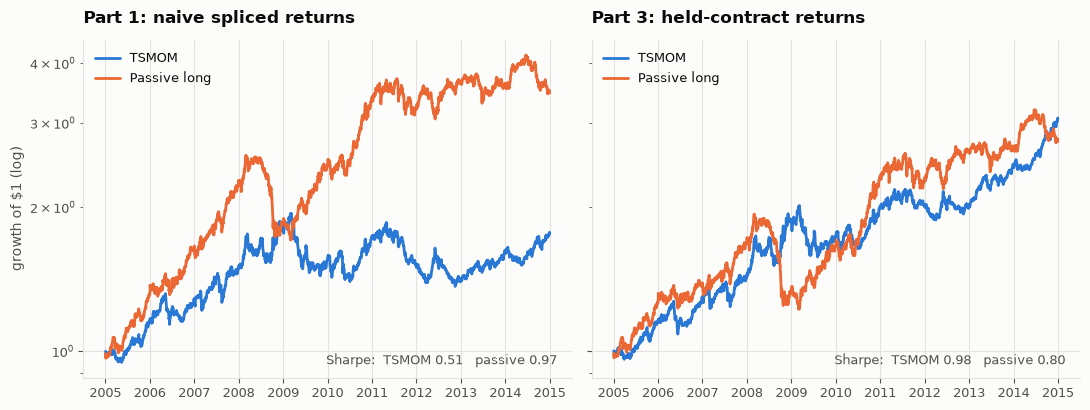

In [25]:
from cta.backtest import instrument_returns
from cta import plotting

plotting.use_house_style()
naive_book = diversified_tsmom(universe, lookback=252, vol_window=60,
                               cost_bps=2.0, construction='naive_spliced')
w = slice('2005-01-01', '2014-12-31')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (book, title) in zip(axes, [(naive_book, 'Part 1: naive spliced returns'),
                                    (corrected, 'Part 3: held-contract returns')]):
    plotting.growth_chart(growth_of_one(book['strategy'].loc[w]),
                          growth_of_one(book['benchmark'].loc[w]),
                          title, ax=ax)
    ax.set_xlabel('')
    sr_s = sharpe_ratio(book['strategy'].loc[w])
    sr_b = sharpe_ratio(book['benchmark'].loc[w])
    ax.annotate(f'Sharpe:  TSMOM {sr_s:.2f}   passive {sr_b:.2f}',
                xy=(0.97, 0.04), xycoords='axes fraction', ha='right',
                fontsize=9, color=plotting.TEXT_SECONDARY)
axes[1].set_ylabel('')
fig.tight_layout()
plt.show()

The two panels differ in one line of code. On the left the passive book appears
unbeatable; on the right the ordering is the other way round and TSMOM agrees with the
Sharpe above 1 that Moskowitz-Ooi-Pedersen report. The gap between the panels is the
roll carry the always-long book was collecting.

The conclusion reverses. TSMOM exceeds the vol-matched passive benchmark on every
window, at comparable realised volatility (~12% against ~13%) and roughly half the
drawdown. Part 1's finding that trend-following underperforms was an artifact.

The corrected result also agrees with the literature this project benchmarks against:
Moskowitz-Ooi-Pedersen report Sharpe > 1 for diversified TSMOM. The full-history Sharpe
(~1.5) is higher than the literature's; costs beyond execution, financing, margin and
capacity are unmodelled here, so it should be read as an upper bound rather than a
forecast.

### Transaction cost sensitivity

The ranking should not depend on the assumed rate, so it is tested across a range.

In [26]:
cost_rows = []
for bps in [0.0, 1.0, 2.0, 5.0, 10.0]:
    res = diversified_tsmom(universe, lookback=252, vol_window=60, cost_bps=bps)
    w = slice('2005-01-01', '2014-12-31')
    cost_rows.append({'cost (bps)': bps,
                      'TSMOM Sharpe': sharpe_ratio(res['strategy'].loc[w]),
                      'passive Sharpe': sharpe_ratio(res['benchmark'].loc[w])})

pd.DataFrame(cost_rows).style.format({'cost (bps)': '{:.0f}', 'TSMOM Sharpe': '{:.2f}',
                                      'passive Sharpe': '{:.2f}'}).hide(axis='index')

cost (bps),TSMOM Sharpe,passive Sharpe
0,1.05,0.80
1,1.01,0.80
2,0.98,0.80
5,0.88,0.79
10,0.72,0.77


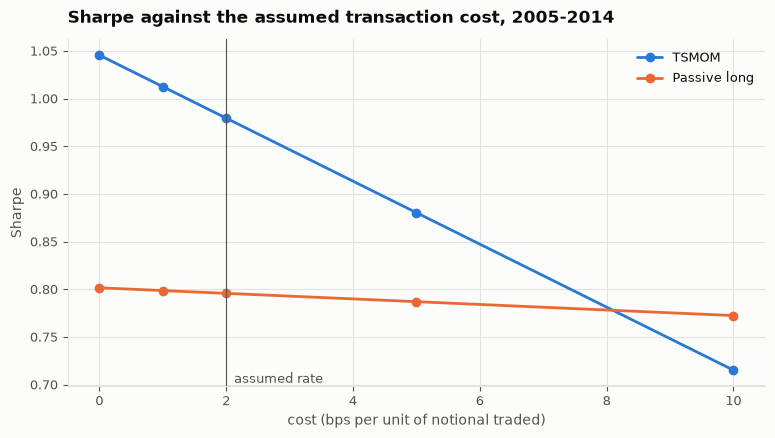

In [27]:
from cta import plotting

plotting.use_house_style()
costs = pd.DataFrame(cost_rows)

ax = plt.gca()
ax.plot(costs['cost (bps)'], costs['TSMOM Sharpe'], marker='o',
        color=plotting.STRATEGY, label='TSMOM')
ax.plot(costs['cost (bps)'], costs['passive Sharpe'], marker='o',
        color=plotting.BENCHMARK, label='Passive long')
ax.axvline(2.0, color=plotting.TEXT_SECONDARY, linewidth=0.8)
ax.annotate('  assumed rate', xy=(2.0, ax.get_ylim()[0]), fontsize=9,
            color=plotting.TEXT_SECONDARY, va='bottom')
ax.set_title('Sharpe against the assumed transaction cost, 2005-2014')
ax.set_xlabel('cost (bps per unit of notional traded)')
ax.set_ylabel('Sharpe')
ax.legend(loc='upper right')
plt.show()

The trend book pays more as the rate rises, since it trades about six times as much as
the control, so the two lines converge. They do not cross inside the range tested, so
the ordering does not depend on the assumed rate being exactly 2bp.

### Out-of-sample: rolling walk-forward with a point-in-time universe

This implements potential fix 3 from Part 1. The brief requires ≥5 years
out-of-sample and recommends rolling walk-forward.

TSMOM's parameters are fixed a priori from the literature (12-month lookback, 60-day vol
window), so there is little to overfit in the signal itself. The material in-sample
contamination is universe selection: the screen that produced 77 markets used 2014-vintage
information. `walk_forward` removes it, re-deriving the universe at each year-end from data
available then and trading the following year out-of-sample.

In [28]:
from cta.backtest import walk_forward

wf = walk_forward(start_year=2005, end_year=2014, cost_bps=2.0)

wf_rows = [{'strategy': 'TSMOM', **{'Sharpe': sharpe_ratio(wf['strategy']),
            'cum. return': growth_of_one(wf['strategy']).iloc[-1] - 1,
            'max DD': max_drawdown(wf['strategy'])}},
           {'strategy': 'passive long', **{'Sharpe': sharpe_ratio(wf['benchmark']),
            'cum. return': growth_of_one(wf['benchmark']).iloc[-1] - 1,
            'max DD': max_drawdown(wf['benchmark'])}}]
display(pd.DataFrame(wf_rows).style.format({'Sharpe': '{:.2f}', 'cum. return': '{:.1%}',
                                            'max DD': '{:.1%}'}).hide(axis='index'))

print('universe size by year (point-in-time):',
      {y: len(u) for y, u in wf['universes'].items()})

strategy,Sharpe,cum. return,max DD
TSMOM,0.93,193.5%,-22.7%
passive long,0.78,173.3%,-37.4%


universe size by year (point-in-time): {2005: 77, 2006: 77, 2007: 80, 2008: 85, 2009: 85, 2010: 85, 2011: 85, 2012: 85, 2013: 85, 2014: 85}


The walk-forward result is weaker than the full-sample-universe version. Removing universe
look-ahead costs Sharpe, and this is the figure quoted out-of-sample.

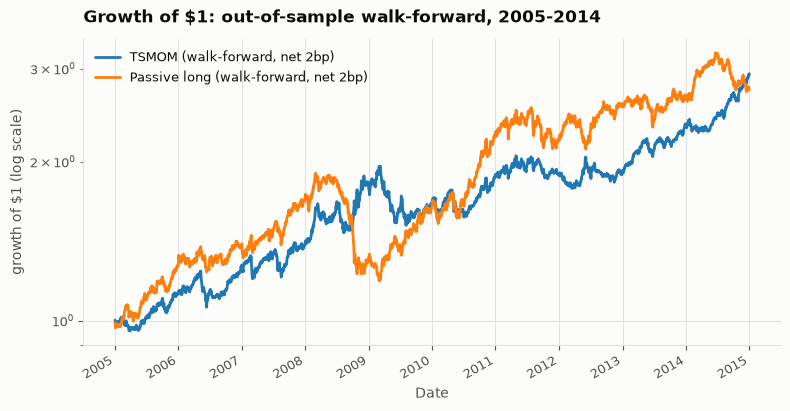

In [29]:
growth = pd.DataFrame({
    'TSMOM (walk-forward, net 2bp)': growth_of_one(wf['strategy']),
    'Passive long (walk-forward, net 2bp)': growth_of_one(wf['benchmark']),
})
growth.plot(logy=True, title='Growth of $1: out-of-sample walk-forward, 2005-2014')
plt.ylabel('growth of $1 (log scale)')
plt.show()

### What survives of the two regime overlays

Potential fixes 1 and 2 from Part 1, retested on corrected returns. Part 1 concluded
that the correlation overlay hurt and the trend-efficiency overlay helped
slightly. Both conclusions were computed on contaminated returns, and the correlation
overlay was additionally driven by an estimator that returned a constant.

Re-run on corrected returns:

In [30]:
corrected_returns = instrument_returns(universe)
regime = correlation_regime_scale(universe, corr_window=120, threshold_lookback=504,
                                  returns=corrected_returns)

variants = {
    'baseline': diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns),
    '+ correlation regime': diversified_tsmom(universe, cost_bps=2.0,
                                              returns=corrected_returns, regime_scale=regime),
    '+ trend efficiency': diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                                            trend_efficiency_window=252),
}
w = slice('2005-01-01', '2014-12-31')
pd.DataFrame([{'variant': k,
               'Sharpe': sharpe_ratio(v['strategy'].loc[w]),
               'cum. return': growth_of_one(v['strategy'].loc[w]).iloc[-1] - 1,
               'max DD': max_drawdown(v['strategy'].loc[w])}
              for k, v in variants.items()]
             ).style.format({'Sharpe': '{:.2f}', 'cum. return': '{:.1%}', 'max DD': '{:.1%}'}
                            ).hide(axis='index')

variant,Sharpe,cum. return,max DD
baseline,0.98,207.3%,-21.9%
+ correlation regime,1.25,207.3%,-12.2%
+ trend efficiency,0.97,325.2%,-28.5%


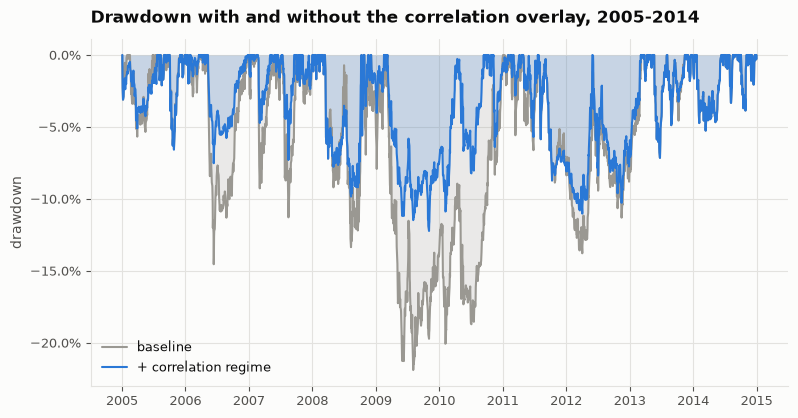

In [31]:
import matplotlib as mpl

from cta import plotting

plotting.use_house_style()
w = slice('2005-01-01', '2014-12-31')
pairs = [('baseline', variants['baseline']['strategy'].loc[w], plotting.SUPERSEDED),
         ('+ correlation regime', variants['+ correlation regime']['strategy'].loc[w],
          plotting.STRATEGY)]

ax = plt.gca()
handles = []
for label, series, colour in pairs:
    wealth = (1 + series).cumprod()
    underwater = wealth / wealth.cummax() - 1
    ax.fill_between(underwater.index, underwater.to_numpy(), 0,
                    color=colour, alpha=0.18, linewidth=0)
    line, = ax.plot(underwater.index, underwater.to_numpy(),
                    color=colour, label=label, linewidth=1.5)
    handles.append(line)

ax.set_title('Drawdown with and without the correlation overlay, 2005-2014')
ax.set_ylabel('drawdown')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
# legend from the line handles only: the fills are the same two series drawn twice
ax.legend(handles=handles, loc='lower left')
plt.show()

The overlay does not change where the book loses money, only how far it falls: the same
episodes appear in both lines, shallower in one. This is what a risk dial looks like
when it works, and it is why the claim made for it is better risk control rather than
added return.

The trend-efficiency overlay does not earn its place (0.97 against 0.98 baseline). It raises
raw return by taking more risk and returns the gain in drawdown. Part 1's per-asset-class
explanation of why it helped or hurt was reasoning about contaminated returns.

The correlation overlay reverses Part 1's finding twice over. Part 1 recorded it as a
failure, a verdict that came from an estimator that returned a constant. Corrected, it
delivers essentially the same terminal return for materially less risk: volatility
11.8%  -> 9.0%, max drawdown −21.9%  -> −12.2%. This is the behaviour Hurst-Ooi-Pedersen
predict - cut exposure when markets stop moving independently, since that is when
trend-following has fewer distinct positions available.

Two tests were run before accepting it.

In [32]:
# Test 1: is the gap real, or would ANY series with this on/off pattern do as well?
# Circular-shift null -- preserves the overlay's duty cycle and persistence, destroys
# only its alignment to what markets were actually doing.
rng = np.random.default_rng(0)
vals = regime.dropna()
null = []
for _ in range(200):
    k = rng.integers(1, len(vals))
    shifted = pd.Series(np.roll(vals.to_numpy(), k), index=vals.index)
    s = diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                          regime_scale=shifted)['strategy'].loc[w]
    null.append(sharpe_ratio(s))

null = np.array(null)
actual = sharpe_ratio(variants['+ correlation regime']['strategy'].loc[w])
print(f'null Sharpe over 200 random shifts: mean {null.mean():.3f}, sd {null.std():.3f}')
print(f'actual overlay Sharpe:              {actual:.3f}')
print(f'z-score vs null: {(actual - null.mean()) / null.std():.2f} (percentile {100 * (null < actual).mean():.0f})')

null Sharpe over 200 random shifts: mean 0.932, sd 0.099
actual overlay Sharpe:              1.250
z-score vs null: 3.23 (percentile 100)


The timing carries information: a randomly aligned overlay with the same duty cycle averages
~0.93.

**Test 2: survival out-of-sample**, where the universe is also chosen point-in-time.
This is the stricter test.

In [33]:
oos_rows = []
for label, kw in [('baseline', {}), ('+ correlation regime', {'regime_scale': regime})]:
    strict = diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                               **kw)['strategy'].loc['2010-01-01':'2014-12-31']
    wf_s = walk_forward(start_year=2005, end_year=2014, cost_bps=2.0, **kw)['strategy']
    oos_rows.append({'variant': label,
                     '2010-2014 Sharpe': sharpe_ratio(strict),
                     '2010-2014 max DD': max_drawdown(strict),
                     'walk-forward Sharpe': sharpe_ratio(wf_s),
                     'walk-forward max DD': max_drawdown(wf_s)})

pd.DataFrame(oos_rows).style.format({'2010-2014 Sharpe': '{:.2f}', '2010-2014 max DD': '{:.1%}',
                                     'walk-forward Sharpe': '{:.2f}', 'walk-forward max DD': '{:.1%}'}
                                    ).hide(axis='index')

variant,2010-2014 Sharpe,2010-2014 max DD,walk-forward Sharpe,walk-forward max DD
baseline,1.12,-13.8%,0.93,-22.7%
+ correlation regime,1.32,-11.0%,1.19,-13.2%


It holds in both: 0.93  -> 1.19 in the point-in-time walk-forward, with drawdown cut from
−22.7% to −13.2%. This is the strictest test in the project and the figure worth quoting.

### Caveats

- The overlay's specification was chosen with full-sample knowledge - 120-day
  correlation window, 504-day median threshold, halve-exposure rule. The signal is causal
  and the universe is point-in-time, but the design is not; a clean test requires a
  specification fixed before any of this data is seen.
- Two overlays were tried. Allowing for multiple testing, one surviving at z ≈ 3 is
  suggestive rather than conclusive.
- It reduces risk rather than adding return. Terminal return is essentially unchanged,
  and levering the baseline to the overlay's 9% volatility captures much of the same
  Sharpe. The supported claim is improved risk control, not alpha.

**Conclusion for the write-up.** The strategy is plain diversified TSMOM. The correlation
overlay is a literature-grounded risk-management addition, reported with the caveats above.
The trend-efficiency overlay is dropped.

# Part 4 - Variants tested, and the outcome of each

Part 3 fixed the return construction and re-established the baseline. This part logs
everything tried after that, including what did not work, so that the claims in
`03_final_writeup.ipynb` about rejected variants are reproducible rather than asserted, and
so that the final specification can be read as the survivor of a documented search.

Three candidates, one adopted:

| Candidate | Source | Outcome |
|---|---|---|
| Book-level volatility target | Hurst-Ooi-Pedersen | adopted |
| Multi-horizon signal blend | Hurst-Ooi-Pedersen | not adopted |
| Concentrating the universe | the standard suggestion | rejected |

In [34]:
import numpy as np
import pandas as pd

from cta.backtest import (correlation_ranked_universe, diversified_tsmom,
                          instrument_returns, universe_breadth_study, walk_forward)
from cta.data import curated_futures_universe
from cta.metrics import (annualized_volatility, max_drawdown, sharpe_ratio,
                         sharpe_difference_interval)

universe = curated_futures_universe()
part4_returns = instrument_returns(universe)

WF = slice('2005-01-01', '2014-12-31')
OOS = slice('2010-01-01', '2014-12-31')
COSTS_BPS = 2.0
VOL_TARGET = 0.10


def summarise(series):
    return {'walk-forward window Sharpe': sharpe_ratio(series.loc[WF]),
            'held-out Sharpe': sharpe_ratio(series.loc[OOS]),
            'walk-forward vol': annualized_volatility(series.loc[WF]),
            'walk-forward max DD': max_drawdown(series.loc[WF])}


P4_FORMATS = {'walk-forward window Sharpe': '{:.2f}', 'held-out Sharpe': '{:.2f}',
              'walk-forward vol': '{:.1%}', 'walk-forward max DD': '{:.1%}'}

## 4.1 Book-level volatility target - adopted

Per-market vol targeting sizes each position to 40% annualised but does not determine the
volatility of the book, which also depends on cross-market correlation and on how many
markets are live. Over this sample the trend book's trailing realised vol ranges from 7.1%
to 19.5%, carrying its largest risk in 2008.

Hurst-Ooi-Pedersen add a portfolio-level target. It is implemented in
`backtest.portfolio_leverage` and applied to positions, so that the re-levering trades are
charged at the same 2bp as any other trade, rather than to the finished return series.

In [35]:
plain = diversified_tsmom(universe, cost_bps=COSTS_BPS, returns=part4_returns)['strategy']
targeted = diversified_tsmom(universe, cost_bps=COSTS_BPS, returns=part4_returns,
                             portfolio_vol_target=VOL_TARGET)['strategy']

for label, series in [('per-market target only', plain), ('+ book-level target', targeted)]:
    vol = (series.rolling(252).std() * np.sqrt(252)).dropna().loc['1981':]
    print(f'{label:24s} realized vol  min {vol.min():.1%}  max {vol.max():.1%}  sd {vol.std():.2%}')

pd.DataFrame([{'book': 'per-market target only (MOP)', **summarise(plain)},
              {'book': '+ book-level target (HOP)', **summarise(targeted)}]
             ).style.format(P4_FORMATS).hide(axis='index')

per-market target only   realized vol  min 7.1%  max 19.5%  sd 2.41%
+ book-level target      realized vol  min 7.3%  max 12.8%  sd 1.12%


book,walk-forward window Sharpe,held-out Sharpe,walk-forward vol,walk-forward max DD
per-market target only (MOP),0.98,1.12,11.8%,-21.9%
+ book-level target (HOP),1.14,1.27,10.2%,-14.3%


Sharpe improves in both windows, drawdown falls, and the variation in the book's own risk
more than halves. Three reasons this is treated as a real rather than a fitted improvement:

1. It is a specification from a paper rather than a grid search.
2. The 10% level is a units convention. Sharpe is invariant to constant rescaling, so only
   the time variation in leverage can affect it.
3. Applied symmetrically to the passive control it makes the control slightly worse
   (0.80  -> 0.76 walk-forward), so it does not improve whatever it is applied to.

Adopted into the headline specification in `03_final_writeup.ipynb`.

## 4.2 Multi-horizon signal blend - not adopted

MOP use a single 12-month lookback. Hurst-Ooi-Pedersen blend 1-, 3- and 12-month signals
equally, so a position reaches full size only when every horizon agrees.

In [36]:
blends = {'12m (MOP, adopted)': 252,
          '3 + 12m': [63, 252],
          '1 + 3 + 12m (HOP)': [21, 63, 252],
          '1 + 3 + 6 + 12m': [21, 63, 126, 252]}

blend_books = {label: diversified_tsmom(universe, lookback=lb, cost_bps=COSTS_BPS,
                                        returns=part4_returns,
                                        portfolio_vol_target=VOL_TARGET)['strategy']
               for label, lb in blends.items()}

pd.DataFrame([{'signal': k, **summarise(v)} for k, v in blend_books.items()]
             ).style.format(P4_FORMATS).hide(axis='index')

signal,walk-forward window Sharpe,held-out Sharpe,walk-forward vol,walk-forward max DD
"12m (MOP, adopted)",1.14,1.27,10.2%,-14.3%
3 + 12m,1.16,1.19,10.4%,-12.3%
1 + 3 + 12m (HOP),1.20,1.07,10.5%,-12.5%
1 + 3 + 6 + 12m,1.20,1.07,10.4%,-12.9%


findfont: Failed to find font weight demibold, now using 700.


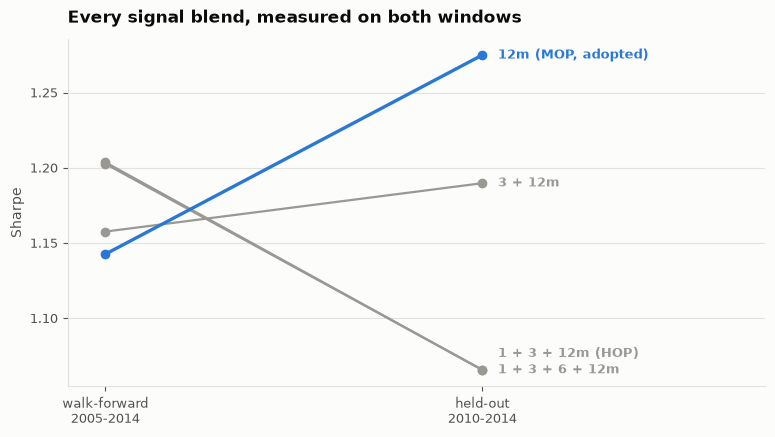

In [37]:
from cta import plotting

plotting.use_house_style()
ax = plt.gca()
ends = []

for label, series in blend_books.items():
    adopted = label.startswith('12m')
    colour = plotting.STRATEGY if adopted else plotting.SUPERSEDED
    y = [sharpe_ratio(series.loc[WF]), sharpe_ratio(series.loc[OOS])]
    ax.plot([0, 1], y, marker='o', color=colour,
            linewidth=2.4 if adopted else 1.6, zorder=3 if adopted else 2)
    ends.append((label, colour, 1, y[1]))

ax.set_xticks([0, 1], ['walk-forward\n2005-2014', 'held-out\n2010-2014'])
ax.set_xlim(-0.1, 1.75)
ax.set_ylabel('Sharpe')
ax.set_title('Every signal blend, measured on both windows')
ax.grid(axis='x', visible=False)
# two blends land on the same Sharpe in both windows, so the end labels are nudged apart
plotting.label_ends_without_overlap(ax, ends)
plt.show()

A line that sloped the same way as the adopted signal would be a candidate. These cross
it. The blends rank above the single 12-month signal on the walk-forward window and
below it on the held-out window, which is the pattern noise produces rather than the one
an improvement produces. The bootstrap intervals below put numbers on that.

In [38]:
# Is any of this distinguishable from the adopted single-horizon signal?
baseline = blend_books['12m (MOP, adopted)']
rows = []
for label, series in blend_books.items():
    if label.startswith('12m'):
        continue
    for window_label, w in [('walk-forward', WF), ('held-out', OOS)]:
        gap = sharpe_difference_interval(series.loc[w], baseline.loc[w])
        rows.append({'signal': label, 'window': window_label,
                     'Sharpe vs 12m': gap['estimate'],
                     'ci_low': gap['ci_low'], 'ci_high': gap['ci_high']})

pd.DataFrame(rows).style.format(
    {'Sharpe vs 12m': '{:+.2f}', 'ci_low': '{:+.2f}', 'ci_high': '{:+.2f}'}
).hide(axis='index')

signal,window,Sharpe vs 12m,ci_low,ci_high
3 + 12m,walk-forward,+0.02,-0.32,+0.33
3 + 12m,held-out,-0.09,-0.57,+0.38
1 + 3 + 12m (HOP),walk-forward,+0.06,-0.37,+0.48
1 + 3 + 12m (HOP),held-out,-0.21,-0.87,+0.42
1 + 3 + 6 + 12m,walk-forward,+0.06,-0.35,+0.46
1 + 3 + 6 + 12m,held-out,-0.21,-0.85,+0.38


This is the variant where selecting on results would have changed the conclusion.

Measured on the walk-forward window, the 1/3/12-month blend improves Sharpe from 1.14 to
1.20. Stopping there would have led to adopting it. On the held-out window it moves the
other way, 1.27  -> 1.07.

Every bootstrap interval in the second table straddles zero. The two windows disagree by
about as much as the noise allows, which indicates a difference this dataset cannot resolve
rather than an improvement.

**Not adopted** - not because Hurst-Ooi-Pedersen are wrong, since they test 137 years of
data against ten years of out-of-sample data here, but because on the available evidence
the two specifications are indistinguishable, and the simpler one is then retained. The
capability remains in `strategies.blended_momentum_signal` so that this table re-runs.

## 4.3 Concentrating the universe - rejected

The standard suggestion for a 77-market book is to trade fewer, better-understood markets.
Per-market Sharpes here are around 0.2-0.3, so almost the entire portfolio result is a
diversification effect, which makes the suggestion worth measuring.

Two tests: how Sharpe scales with the number of markets, using random subsets since any rule
for choosing the best N is itself a hindsight decision; and whether concentrating into
correlated markets helps, with the correlation ranking computed point-in-time at end-2009 so
that the selection cannot use later information.

In [39]:
breadth = universe_breadth_study(universe, sizes=[5, 10, 20, 40, 60, len(universe)],
                                 window=OOS, n_draws=15, cost_bps=COSTS_BPS,
                                 returns=part4_returns, portfolio_vol_target=VOL_TARGET)
breadth.groupby('n_markets')['sharpe'].agg(['mean', 'std', 'min', 'max']).style.format('{:.2f}')

,mean,std,min,max
n_markets,,,,
5,0.61,0.35,0.07,1.23
10,0.91,0.40,0.33,1.99
20,1.00,0.24,0.51,1.41
40,1.16,0.23,0.82,1.61
60,1.26,0.18,0.99,1.65
77,1.27,nan,1.27,1.27


In [40]:
rows = []
for label, most in [('20 most correlated', True), ('20 least correlated', False)]:
    subset = correlation_ranked_universe(universe, 20, '2009-12-31',
                                         most_correlated=most, returns=part4_returns)
    book = diversified_tsmom(subset, cost_bps=COSTS_BPS, portfolio_vol_target=VOL_TARGET,
                             returns={s: part4_returns[s] for s in subset})['strategy']
    rows.append({'universe': label, **summarise(book)})
rows.append({'universe': 'all 77 markets', **summarise(targeted)})

pd.DataFrame(rows).style.format(P4_FORMATS).hide(axis='index')

universe,walk-forward window Sharpe,held-out Sharpe,walk-forward vol,walk-forward max DD
20 most correlated,0.54,0.49,10.3%,-23.7%
20 least correlated,1.23,1.87,10.0%,-15.8%
all 77 markets,1.14,1.27,10.2%,-14.3%


Mean out-of-sample Sharpe rises monotonically with breadth (0.61 at five markets to 1.27 at
77) and the dispersion across draws halves (sd 0.35  -> 0.18). A small book is not only worse
on average: which markets are selected matters more than the strategy does. At ten markets
the best of fifteen draws returned 1.99 and the worst 0.33.

Concentrating into the 20 most mutually correlated markets more than halves out-of-sample
Sharpe, to 0.49. Correlated markets are the same position under different tickers, and the
book pays full transaction costs to hold it more than once.

**Rejected.** The finding is promoted to a headline exhibit in `03_final_writeup.ipynb` §7
as the clearest direct evidence that the edge is diversification rather than prediction.

## Part 4 summary

| Candidate | Walk-forward | Held-out | Verdict |
|---|---|---|---|
| baseline (12m, per-market vol target) | 0.98 | 1.12 | - |
| + book-level vol target | 1.14 | 1.27 | adopted |
| + 1/3/12-month blend | 1.20 | 1.07 | not adopted - inconsistent across windows, inside the noise |
| trend-efficiency boost (§Part 1) | ~flat | ~flat | not adopted |
| 20 most-correlated markets only | 0.54 | 0.49 | rejected |
| correlation regime overlay (on the Part 3 book) | 1.19 | - | secondary result only; specification is in-sample. On top of the vol-targeted book it gives 1.21 - see `03` §11 |

One of five candidates survived, and it is the one specified by a paper rather than found by
searching. The final specification is in `03_final_writeup.ipynb`.